<a href="https://colab.research.google.com/github/kcf1/fina4359-quant-trading/blob/asm1/fina4359_asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINA4359 Assignment 1
1. Tsang Chun Kit (3036080288)
2. Tam Pai Lok (303592647)
3. Kan Chi Fu (3035807902)

# Q1. Asset allocation

In [31]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"  # multiple output per jupyter notebook code block
%matplotlib inline

In [32]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.labelsize'] = 'small'
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['xtick.labelsize'] = 'small'
plt.rcParams['ytick.labelsize'] = 'small'

## 1.1

In [33]:
ret = pd.read_excel('damodaran.xlsx', sheet_name='Returns by year', skiprows=1, index_col=0)
ret.mean()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,0
S&P 500 (includes dividends),0.118547
US Small cap (bottom decile),0.177752
3-month T.Bill,0.034149
US T. Bond (10-year),0.048224
Baa Corporate Bond,0.069019
Real Estate,0.043778
Gold*,0.073610
Stocks - Bills,0.084397
Stocks - Bonds,0.070323
Small Cap Premium (S&P 500 minus Bottom Decile),0.059206


In [34]:
# Select all the asset classes
returns = ret.iloc[:, :7]

# Use T-Bill as risk-free rate
risk_free_rate = ret.iloc[:, 2]

# Calculate Sharpe Ratio: (mean return - mean risk free rate) / std dev
# For each asset, subtract the risk-free rate from returns, then calculate
excess_returns = returns.subtract(risk_free_rate, axis=0)
empirical = pd.DataFrame(excess_returns.mean() / excess_returns.std(), columns=['Sharpe Ratio'])
cum_returns = (1 + returns).prod() - 1
empirical["Annualized Return"] = (1 + cum_returns) ** (1/len(returns)) - 1

empirical

,Sharpe Ratio,Annualized Return
S&P 500 (includes dividends),0.428332,0.100177
US Small cap (bottom decile),0.372763,0.119818
3-month T.Bill,NaN,0.033716
US T. Bond (10-year),0.184365,0.045346
Baa Corporate Bond,0.442211,0.066296
Real Estate,0.144310,0.041980
Gold*,0.185166,0.056091


In [35]:
returns.corr()

,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
S&P 500 (includes dividends),1.000000,0.720687,-0.021436,0.018336,0.404233,0.148432,-0.056180
US Small cap (bottom decile),0.720687,1.000000,-0.151192,-0.101603,0.312088,0.153304,0.011291
3-month T.Bill,-0.021436,-0.151192,1.000000,0.279040,0.119909,0.077605,0.134622
US T. Bond (10-year),0.018336,-0.101603,0.279040,1.000000,0.658236,-0.108288,-0.009333
Baa Corporate Bond,0.404233,0.312088,0.119909,0.658236,1.000000,-0.043207,0.016573
Real Estate,0.148432,0.153304,0.077605,-0.108288,-0.043207,1.000000,0.078504
Gold*,-0.056180,0.011291,0.134622,-0.009333,0.016573,0.078504,1.000000


## 1.2

In [36]:
last_30_years = returns.iloc[-30:]
prev_years = returns.iloc[:-30]

last_30_years.describe()
prev_years.describe()

cumulative_returns_last_30 = (1 + last_30_years).prod() - 1
cumulative_returns_prev = (1 + prev_years).prod() - 1
print("Cumulative Returns (Last 30 Years):")
print(cumulative_returns_last_30)
print("Cumulative Returns (Previous Years):")
print(cumulative_returns_prev)

,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.117971,0.123887,0.023540,0.042300,0.065319,0.049423,0.098116
std,0.175865,0.259479,0.021201,0.087869,0.068883,0.063001,0.181723
min,-0.365523,-0.446800,0.000300,-0.178282,-0.152281,-0.119952,-0.276142
25%,0.027824,-0.077350,0.001925,0.004541,0.025285,0.027403,-0.005891
50%,0.157516,0.149600,0.018050,0.034258,0.086662,0.054787,0.068941
75%,0.256711,0.223225,0.047050,0.101422,0.107101,0.088893,0.223696
max,0.331037,0.912300,0.060000,0.201013,0.199585,0.188646,0.662158


,S&P 500 (includes dividends),US Small cap (bottom decile),3-month T.Bill,US T. Bond (10-year),Baa Corporate Bond,Real Estate,Gold*
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.118800,0.201516,0.038830,0.050837,0.070651,0.041287,0.062798
std,0.202781,0.421269,0.032666,0.075343,0.080071,0.061595,0.228646
min,-0.438375,-0.539400,0.000358,-0.080367,-0.156808,-0.104664,-0.325986
25%,-0.016723,-0.061650,0.010637,0.008986,0.019385,0.008046,-0.004261
50%,0.133102,0.184000,0.031923,0.032822,0.055561,0.029410,0.000000
75%,0.254554,0.427500,0.058298,0.070886,0.117985,0.072650,0.068908
max,0.525633,1.466000,0.140362,0.328145,0.290525,0.241017,1.265487


Cumulative Returns (Last 30 Years):
S&P 500 (includes dividends)    17.710268
US Small cap (bottom decile)    14.193249
3-month T.Bill                   0.997348
US T. Bond (10-year)             2.114997
 Baa Corporate Bond              5.261052
Real Estate                      3.029320
Gold*                           10.213553
dtype: float64
Cumulative Returns (Previous Years):
S&P 500 (includes dividends)     617.381897
US Small cap (bottom decile)    4312.182699
3-month T.Bill                    11.908600
US T. Bond (10-year)              23.775504
 Baa Corporate Bond               85.171482
Real Estate                       12.962697
Gold*                             17.750000
dtype: float64


In [37]:
# Function to calculate portfolio Sharpe ratio
def portfolio_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (portfolio_return - risk_free_rate) / portfolio_std
    return -sharpe  # negative for minimization

# Function to find tangent portfolio
def find_tangent_portfolio(returns, risk_free_rate):
    n_assets = returns.shape[1]
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    # Initial guess: equal weights
    x0 = np.array([1.0/n_assets] * n_assets)

    # Constraints: weights sum to 1
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

    # Bounds: weights between 0 and 1 (long-only)
    bounds = tuple((0, 1) for _ in range(n_assets))

    result = minimize(portfolio_sharpe, x0, args=(mean_returns, cov_matrix, risk_free_rate),
                     method='SLSQP', bounds=bounds, constraints=constraints)

    return result.x

# Calculate rolling tangent portfolios
lookback = 3

# For last 30 years
last_30_years_weights = []
last_30_years_dates = []

for i in range(lookback, len(last_30_years) + 1):
    window = last_30_years.iloc[i-lookback:i]
    rf_rate = risk_free_rate.iloc[i-lookback:i].mean()
    weights = find_tangent_portfolio(window, rf_rate)
    last_30_years_weights.append(weights)
    last_30_years_dates.append(last_30_years.index[i-1])

# For previous years
prev_years_weights = []
prev_years_dates = []

for i in range(lookback, len(prev_years) + 1):
    window = prev_years.iloc[i-lookback:i]
    rf_rate = risk_free_rate.iloc[i-lookback:i].mean()
    weights = find_tangent_portfolio(window, rf_rate)
    prev_years_weights.append(weights)
    prev_years_dates.append(prev_years.index[i-1])

# Create dataframes for results
tangent_portfolio_last_30 = pd.DataFrame(last_30_years_weights,
                                         index=last_30_years_dates,
                                         columns=returns.columns)
tangent_portfolio_prev = pd.DataFrame(prev_years_weights,
                                      index=prev_years_dates,
                                      columns=returns.columns)

In [38]:
print("Mean Tangent Portfolio Weights (Last 30 Years):")
print(tangent_portfolio_last_30.mean())
print("Mean Tangent Portfolio Weights (Previous Years):")
print(tangent_portfolio_prev.mean())

Mean Tangent Portfolio Weights (Last 30 Years):
S&P 500 (includes dividends)    0.123667
US Small cap (bottom decile)    0.054123
3-month T.Bill                  0.171207
US T. Bond (10-year)            0.134841
 Baa Corporate Bond             0.105118
Real Estate                     0.337910
Gold*                           0.073423
dtype: float64
Mean Tangent Portfolio Weights (Previous Years):
S&P 500 (includes dividends)    0.054177
US Small cap (bottom decile)    0.054981
3-month T.Bill                  0.347932
US T. Bond (10-year)            0.110927
 Baa Corporate Bond             0.186353
Real Estate                     0.172462
Gold*                           0.073625
dtype: float64


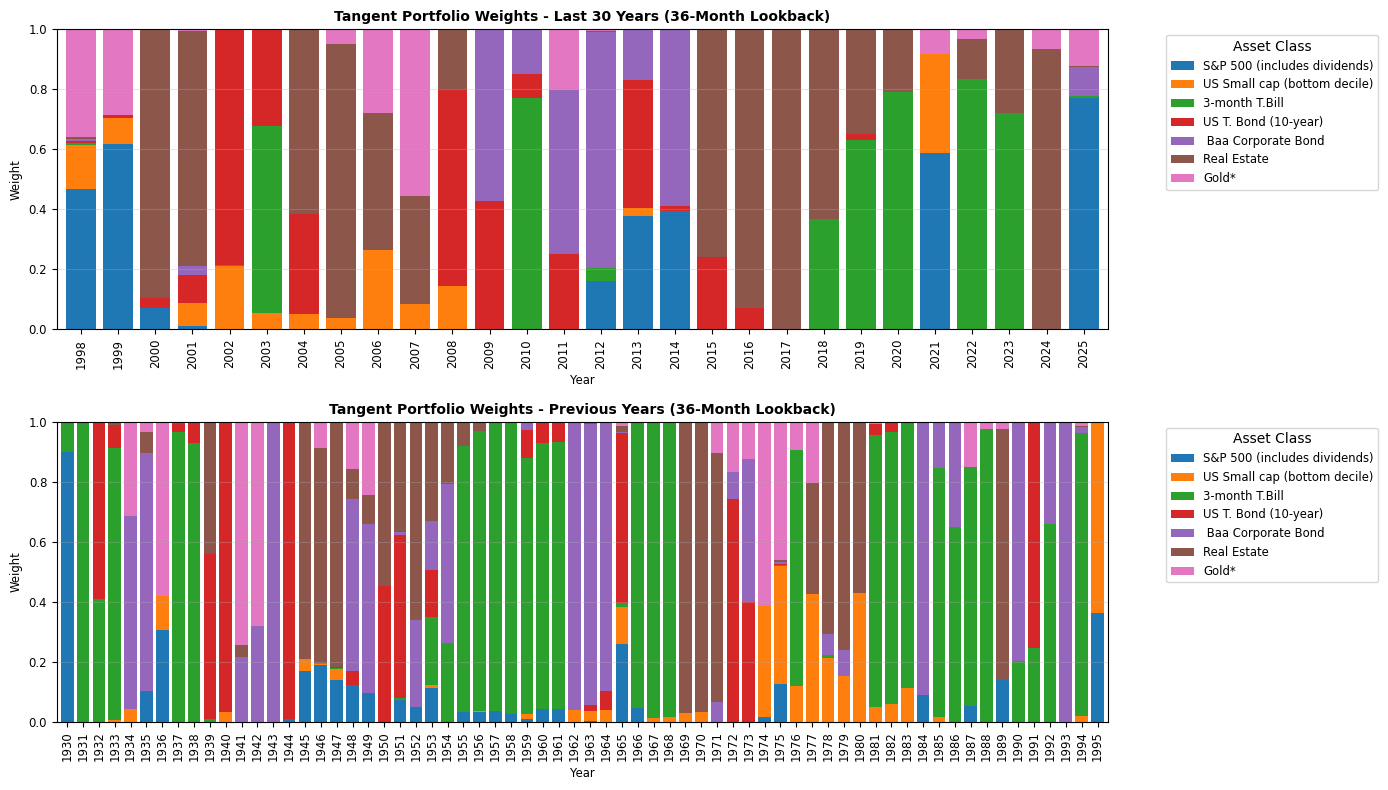

In [39]:
# Plot tangent portfolio weights for last 30 years
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Last 30 years
tangent_portfolio_last_30.plot(kind='bar', stacked=True, ax=ax1, width=0.8)
ax1.set_title('Tangent Portfolio Weights - Last 30 Years (36-Month Lookback)', fontsize='medium', fontweight='bold')
ax1.set_ylabel('Weight', fontsize='small')
ax1.set_xlabel('Year', fontsize='small')
ax1.legend(title='Asset Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Previous years
tangent_portfolio_prev.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
ax2.set_title('Tangent Portfolio Weights - Previous Years (36-Month Lookback)', fontsize='medium', fontweight='bold')
ax2.set_ylabel('Weight', fontsize='small')
ax2.set_xlabel('Year', fontsize='small')
ax2.legend(title='Asset Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show();

In [40]:
# Calculate portfolio return series for the tangent portfolios (weights * returns)
pf_returns_last_30 = (tangent_portfolio_last_30 * last_30_years.reindex(tangent_portfolio_last_30.index)).sum(axis=1)
pf_returns_prev = (tangent_portfolio_prev * prev_years.reindex(tangent_portfolio_prev.index)).sum(axis=1)

# Cumulative returns
cum_pf_last_30 = (1 + pf_returns_last_30).cumprod() - 1
cum_pf_prev = (1 + pf_returns_prev).cumprod() - 1

# Summary
annualized_return_last_30 = (cum_pf_last_30.iloc[-1] + 1) ** (1 / len(pf_returns_last_30)) - 1
annualized_return_prev = (cum_pf_prev.iloc[-1] + 1) ** (1 / len(pf_returns_prev)) - 1
print("Annualized Return (Last 30 Years):", annualized_return_last_30)
print("Annualized Return (Previous Years):", annualized_return_prev)

Annualized Return (Last 30 Years): 0.08927795144786765
Annualized Return (Previous Years): 0.08257544342397982


## 1.6

In [12]:
mpf = pd.read_csv('mpf_category_annual_returns.csv', index_col=0)
mpf_cum_ret = (1 + mpf).prod() - 1
mpf_cum_ret["hk_GlobalEquityLargeCap"] - mpf_cum_ret["hk_GreaterChinaEquity"]

np.float64(0.11999858823689147)

In [13]:
from scipy.optimize import brentq

def npv(rate, cash_flows):
    """Calculate Net Present Value given a discount rate"""
    return sum([cf / (1 + rate)**i for i, cf in enumerate(cash_flows)])

def irr_with_annual_contrib(returns, contrib=1.0, growth=0.00):
    """
    returns : pd.Series of annual returns
    contrib : amount put in at the *start* of each year
    growth  : annual growth rate of contribution (default 3%)
    """
    fv = 0.0
    for r in returns:
        fv = (fv + contrib) * (1 + r)      # deposit then earn
        contrib *= 1 + growth  # increase contribution by growth per year
    # cash‑flows: negative contributions for years 0…n‑1, final positive value
    flows = [-contrib] * len(returns) + [fv]

    # Find IRR where NPV = 0
    try:
        irr = brentq(lambda r: npv(r, flows), -0.99, 1.0)
        return irr
    except ValueError:
        print("Could not find IRR in range")
        return np.nan

irr_hk = irr_with_annual_contrib(mpf["hk_GreaterChinaEquity"])
irr_global   = irr_with_annual_contrib(mpf["hk_GlobalEquityLargeCap"])

print("IRR:")
print(f" Greater China Equity → {irr_hk:.2%}")
print(f" Global Equity → {irr_global:.2%}")

IRR:
 Greater China Equity → 2.78%
 Global Equity → 6.00%


# Q2. Smart beta ETFs

In [15]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel('FINA4359_SPMO.xlsx', sheet_name='Sheet1')
df['ret'] = (df['SPMO'] / df['SPMO'].shift(1) - 1) * 100
df = df.dropna(subset=['ret'])
df['excess_ret'] = df['ret'] - df['RF']

X = sm.add_constant(df[['Mkt-RF', 'MOM']])
y = df['excess_ret']
model = sm.OLS(y, X).fit()
print("Q1")
print("───────────────────────────────────────────────────────────────")
print("Two-factor regression: SPMO excess return ~ Mkt-RF + MOM")
print(f"Alpha (const)         : {model.params['const']:9.4f}   t = {model.tvalues['const']:6.2f}   p = {model.pvalues['const']:6.4f}")
print(f"Mkt-RF               : {model.params['Mkt-RF']:9.4f}   t = {model.tvalues['Mkt-RF']:6.2f}   p = {model.pvalues['Mkt-RF']:6.4f}")
print(f"Beta MOM             : {model.params['MOM']:.4f}       t = {model.tvalues['MOM']:6.2f}   p = {model.pvalues['MOM']:6.4f}\n")

X = df[['Mkt-RF', 'SMB', 'HML', 'MOM']]
X = sm.add_constant(X)
y = df['excess_ret']

model = sm.OLS(y, X).fit()
print("Q4")
print("───────────────────────────────────────────────────────────────")
print("Four-factor regression: SPMO excess return ~ Mkt-RF + SMB + HML + MOM")
print("───────────────────────────────────────────────────────────────")
print(f"Observations          : {len(df):3d}")
print(f"R-squared             : {model.rsquared:8.4f}")
print(f"Adjusted R-squared    : {model.rsquared_adj:8.4f}")
print("\nCoefficients:")
print("───────────────────────────────────────────────────────────────")
print(f"Alpha (const)         : {model.params['const']:9.4f}   t = {model.tvalues['const']:6.2f}   p = {model.pvalues['const']:6.4f}")
print(f"Mkt-RF                : {model.params['Mkt-RF']:9.4f}   t = {model.tvalues['Mkt-RF']:6.2f}   p = {model.pvalues['Mkt-RF']:6.4f}")
print(f"SMB                   : {model.params['SMB']:9.4f}   t = {model.tvalues['SMB']:6.2f}   p = {model.pvalues['SMB']:6.4f}")
print(f"HML                   : {model.params['HML']:9.4f}   t = {model.tvalues['HML']:6.2f}   p = {model.pvalues['HML']:6.4f}")
print(f"MOM                   : {model.params['MOM']:9.4f}   t = {model.tvalues['MOM']:6.2f}   p = {model.pvalues['MOM']:6.4f}")
print("───────────────────────────────────────────────────────────────")

Q1
───────────────────────────────────────────────────────────────
Two-factor regression: SPMO excess return ~ Mkt-RF + MOM
Alpha (const)         :    0.0581   t =   0.37   p = 0.7100
Mkt-RF               :    1.0435   t =  28.81   p = 0.0000
Beta MOM             : 0.4314       t =  10.04   p = 0.0000

Q4
───────────────────────────────────────────────────────────────
Four-factor regression: SPMO excess return ~ Mkt-RF + SMB + HML + MOM
───────────────────────────────────────────────────────────────
Observations          : 121
R-squared             :   0.8819
Adjusted R-squared    :   0.8779

Coefficients:
───────────────────────────────────────────────────────────────
Alpha (const)         :    0.0127   t =   0.08   p = 0.9345
Mkt-RF                :    1.0655   t =  28.89   p = 0.0000
SMB                   :   -0.1465   t =  -2.47   p = 0.0151
HML                   :    0.0346   t =   0.81   p = 0.4181
MOM                   :    0.3992   t =   8.54   p = 0.0000
──────────────────────

In [16]:
import pandas as pd
import statsmodels.api as sm

# Load the data from Excel
df = pd.read_excel('FINA4359_JMOM_MTUM.xlsx', sheet_name='Sheet1')

# Calculate monthly returns (%) for JMOM and MTUM
df['ret_JMOM'] = (df['JMOM'] / df['JMOM'].shift(1) - 1) * 100
df['ret_MTUM'] = (df['MTUM'] / df['MTUM'].shift(1) - 1) * 100

# Calculate excess returns
df['excess_JMOM'] = df['ret_JMOM'] - df['RF']
df['excess_MTUM'] = df['ret_MTUM'] - df['RF']

# Drop rows with NaN (first row and any missing data)
df = df.dropna(subset=['excess_JMOM', 'excess_MTUM', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM'])

# Define factors
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']

# Function to run regression
def run_regression(y, X, hac_lags=3):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    return model

# JMOM regression
X = df[factors]
model_jmom = run_regression(df['excess_JMOM'], X)

# MTUM regression
model_mtum = run_regression(df['excess_MTUM'], X)

# Print JMOM results
print("JMOM Regression Results")
print(model_jmom.summary())

# Print MTUM results
print("\nMTUM Regression Results")
print(model_mtum.summary())

JMOM Regression Results
                            OLS Regression Results                            
Dep. Variable:            excess_JMOM   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     596.3
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.58e-70
Time:                        22:52:38   Log-Likelihood:                -127.39
No. Observations:                  97   AIC:                             268.8
Df Residuals:                      90   BIC:                             286.8
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1336      0

# Q3. Sleuthing via covariances and the basics of performance benchmarking

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import yfinance as yf

## Import macro return data
**CS Global Macro Index at 2x Vol Net of 95 bps**

In [18]:
# Read 'CS Global Macro Index at 2x Vol Net of 95 bps' data.
ret = pd.read_excel('macro_return.xlsx',index_col=0)
# Convert the index to datetime
ret.index = pd.to_datetime(ret.index)
# Convert return data to float.
ret = ret.iloc[:,0].astype(float)


Samples 285 months

Annulized
Mean = 18.16%
Std  = 13.38%
Skew = -0.02
SR   = 1.36



<Axes: xlabel='Date'>

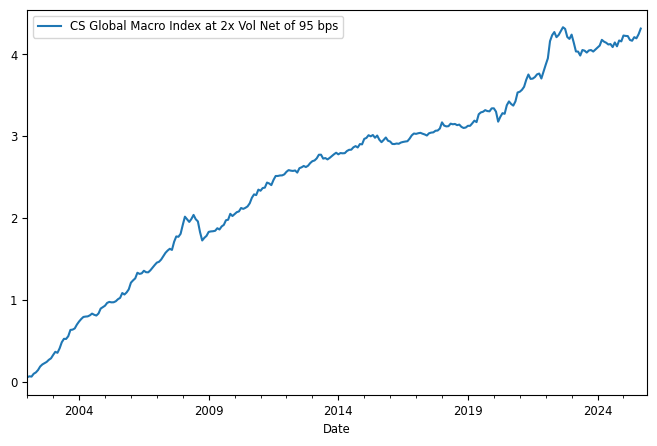

In [19]:
# Annualized mean
m = ret.mean() * 12
# Annualized volatility
s = ret.std() * 12 ** 0.5
# Annualized Sharpe Ratio
sr = m/s
# Monthly skewness
sk = ret.skew()
# Print summary statistics
print(f'''
Samples {ret.count()} months

Annulized
Mean = {m:.2%}
Std  = {s:.2%}
Skew = {sk:.2f}
SR   = {sr:.2f}
''')
# Plot the cumulative sum of the returns.
ret.cumsum().plot()
plt.legend(['CS Global Macro Index at 2x Vol Net of 95 bps'])

## FF5 Benchmark
Conceptually, not a good benchmark:
- Macro invests in all asset classes (incl. fx, rates, commods, etc.) across regions, while FF5 only covers US equity factors
- FF5 might explain partially, as US equities is in fund's investment universe
---
Reasonable benchmark (alpha on FF5 adds uncorrelated return to their portfolio):
- US pension that primarily invest in US equity
- US big corp that are sensitive to US market cycles (high beta)
---
Inappropriate benchmark:
- Relative performance to macro peers
- Investors with access to global markets (not only US)

In [20]:
# Fetch Fama-French 5 factors (2x3 daily breakdown) from Kenneth French's data library.
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
# Convert percentage returns to decimal form
ff5 = ff5 / 100
# Convert the default PeriodIndex to Timestamp and shift to month-end date (e.g., 2000-01-31)
ff5.index = ff5.index.to_timestamp() + pd.offsets.MonthEnd(0)

/tmp/ipykernel_303/3133461993.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
/tmp/ipykernel_303/3133461993.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]


In [21]:
# Create a FF5 regression DataFrame.
reg_df = ff5.copy()
# Get excess return of the macro index by subtracting the risk-free rate.
reg_df['Macro-RF'] = ret - reg_df['RF']
# Drop missing values
reg_df.dropna(inplace=True)

As expected, not a good benchmark:
- FF5 factors did not explained much of the return, resulting in significantly high alpha
- Only US market factor is significant, beta ~0.24, except that HML has a relative small p-value (still insignificant), fund might have some value play
- R^2 is only 10% (90% left unexplained), FF5 failed to track the index properly

In [22]:
# Target is the excess return.
y = reg_df['Macro-RF']
# Factors are FF5
x = reg_df.drop(columns=['RF','Macro-RF'])

In [23]:
model = sm.OLS(y,sm.add_constant(x)).fit()
# Annualized alpha by multiplying 12.
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 14.18%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.358
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.31e-05
Time:                        22:53:44   Log-Likelihood:                 538.01
No. Observations:                 285   AIC:                            -1064.
Df Residuals:                     279   BIC:                            -1042.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0118      0.002      5.165      0.000       0.007       0.016
Mkt-RF         0.2414      0.055      4.409      0.000       0.134       0.349
SMB           -0.0147      0.095     -0.155      0.877      -0.202       0.172
HML            0.1383      0.093      1.494      0.136      -0.044       0.320
RMW            0.0026      0.113      0.023      0.982      -0.220       0.225
CMA            0.1422      0.138      1.034      0.302      -0.129       0.413
==============================================================================
Omnibus:                       29.445   Durbin-Watson:                   1.609
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              121.564
Skew:                           0.247   Prob(JB):                     4.01e-27
Kurtosis:                       6.161   Cond. No.                         69.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Custom benchmark
Factors:
- **Trend** - Bloomberg equal risk trend index
- **Equity Market** - AQR century of factor premia
- **Commodities Market** - AQR century of factor premia
- **US Stock Value** - AQR century of factor premia

In [24]:
# Load custom factors.
fret = pd.read_excel('custom_factors.xlsx',index_col=0)

In [25]:
# Add risk-free rate to DataFrame
fret['RF'] = ff5['RF']
fret.dropna(inplace=True)

In [26]:
# Create a custom benchmark regression DataFrame.
reg_df = fret.copy()
# Get excess return of the macro index by subtracting the risk-free rate.
reg_df['Macro-RF'] = ret - reg_df['RF']
# Drop missing values
reg_df.dropna(inplace=True)

In [27]:
# Target is the excess return.
y = reg_df['Macro-RF']
# Factors are customed
x = reg_df.drop(columns=['RF','Macro-RF'])

About half of the return is replicated with the custom model
- R^2 shows 48%
- All loadings are significant, by selecting factors from the pool
- The benchmark consists of global equity, commodities, covering macro investment universe, and a trend factor that captures the common macro used strategy
- R^2 improved 38% relative to FF5, improvements come from loading **Trend** and **Commodities**, in addition to **Equity** and **Value**

In [28]:
model = sm.OLS(y,sm.add_constant(x)).fit()
# Annualized alpha by multiplying 12.
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 8.16%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     44.35
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.45e-26
Time:                        22:53:46   Log-Likelihood:                 410.92
No. Observations:                 197   AIC:                            -811.8
Df Residuals:                     192   BIC:                            -795.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0068      0.002      3.065      0.002       0.002       0.011
Trend              2.3313      0.308      7.560      0.000       1.723       2.940
Equities           0.1177      0.062      1.903      0.059      -0.004       0.240
Commodities        0.4754      0.056      8.501      0.000       0.365       0.586
US Stock Value     0.1447      0.062      2.348      0.020       0.023       0.266
==============================================================================
Omnibus:                       14.162   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               40.934
Skew:                          -0.016   Prob(JB):                     1.29e-09
Kurtosis:                       5.233   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Rolling 5-year regression R^2:
- The plot showed that the factor explainability is worst in 2014-2018, dropped from 60% to 30%, possibly some non-factor based trades during the period
- Except the above mentioned period, risk premia still contribute 2/3 of the return


<Axes: xlabel='Date'>

(np.float64(11718.0), np.float64(20088.0))

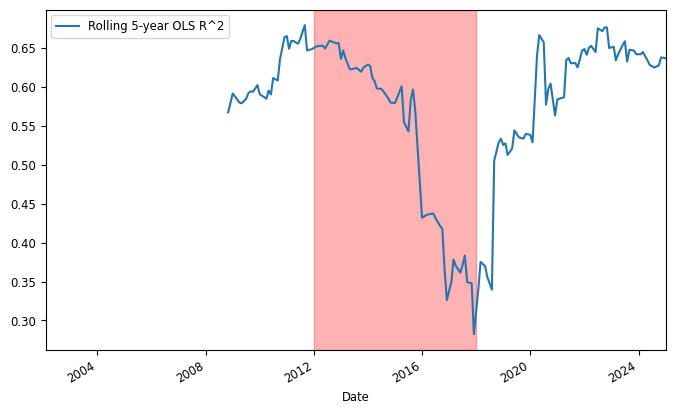

In [51]:
from statsmodels.regression.rolling import RollingOLS
# Uses a 5-year (60-month) rolling window to capture time-varying factor exposures and model fit.
rols = RollingOLS(y,sm.add_constant(x),window=12*5).fit()
# Plot the rolling R-squared values to visualize model explanatory power over time.
rols.rsquared.plot()
plt.axvspan(xmin='2012',xmax='2018',color='red',alpha=0.3)
plt.legend(['Rolling 5-year OLS R^2'])
plt.xlim(y.index[0], y.index[-1])

Replicating portfolio tracks reasonably well in backtest
- Despite that monthly tracking error 3.01%, correlation achieved 69%, and terminal wealth is similar


Tracking error (monthly) 3.01%
Corr 69.30%



<Axes: xlabel='Date'>

<Axes: xlabel='Date'>

<Axes: xlabel='Date'>

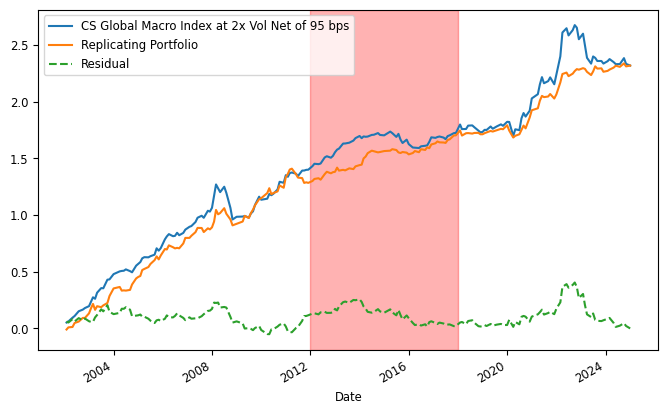

In [52]:
# Generate in-sample replicating portfolio return (yh)
yh = model.predict(sm.add_constant(x))
# Calculate residuals (tracking error components) as actual excess returns minus replicating return.
res = y - yh
# Compute monthly tracking error as the standard deviation of residuals.
err = res.std()
print(f'''
Tracking error (monthly) {err:.2%}
Corr {y.corr(yh):.2%}
''')

# Plot cumulative sum trajectories to visualize long-term performance attribution.
y.cumsum().plot()
yh.cumsum().plot()
res.cumsum().plot(linestyle='--')
plt.axvspan(xmin='2012',xmax='2018',color='red',alpha=0.3)
plt.legend(['CS Global Macro Index at 2x Vol Net of 95 bps','Replicating Portfolio','Residual'])